In [1]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data.sampler import SubsetRandomSampler

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
import os
from PIL import Image
from torch.utils.data import Dataset

class QuickDraw0Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.class_to_idx = {}
        self.idx_to_class = {}  # novo: mapiranje indeks → naziv
        self.classes = []       # novo: lista imena klasa

        # Pronađi sve klase (nazive foldera)
        for idx, class_name in enumerate(sorted(os.listdir(root_dir))):
            class_path = os.path.join(root_dir, class_name)
            if os.path.isdir(class_path):
                self.class_to_idx[class_name] = idx
                self.idx_to_class[idx] = class_name
                self.classes.append(class_name)
                for fname in os.listdir(class_path):
                    if fname.endswith(('.png', '.jpg', '.jpeg')):
                        self.samples.append((os.path.join(class_path, fname), class_name))  # ovde dodaješ naziv klase

    def __len__(self):
        return len(self.samples)

    '''
    def __getitem__(self, idx):
        image_path, class_name = self.samples[idx]
        image = Image.open(image_path).convert('L')
        if self.transform:
            image = self.transform(image)
        return image, class_name  # vraćamo naziv klase kao label
    '''
    
    def __getitem__(self, idx):
        image_path, class_name = self.samples[idx]
        image = Image.open(image_path).convert('L')
        if self.transform:
            image = self.transform(image)
        label = self.class_to_idx[class_name]  # vrati int umesto string
        return image, label

In [3]:
# PREPROCESIRANJE KOJE TREBA DA BUDE UNUTAR DATASETA

preprocess = transforms.Compose([
    transforms.Resize((32, 32)),        
    transforms.ToTensor(),              # pretvara [0,255] → [0.0, 1.0]
    transforms.Normalize([0.5], [0.5])  # normalizuje grayscale kanal
])


In [4]:
import torchvision.transforms as transforms
direc = "balanced_chosen_10_images"


dataset = QuickDraw0Dataset(direc, transform=preprocess)

In [5]:
from torch.utils.data import Dataset, DataLoader, random_split

# Podeli dataset na trening (70%), validacioni (15%) i test set (15%)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

In [6]:
# Kreiraj DataLoader-e
batchsize = 64
train_loader = DataLoader(train_dataset, batch_size=batchsize, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batchsize, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batchsize, shuffle=False)

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
       
        # Layer 1: conv + relu + pool
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
       
        # Layer 2: conv + relu + pool + norm
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.BatchNorm2d(64)
        )
       
        # Layer 3: conv + relu + pool + norm
        self.layer3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.BatchNorm2d(64)
        )
       
        # Fully connected layer 1: flatten + fc + relu + dropout
        self.layer4 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(4*4*64, 500),
            nn.ReLU(),
            nn.Dropout(0.5)
        )
       
        # Fully connected layer 2: fc
        self.layer5 = nn.Linear(500, num_classes) #pisalo 10

    def forward(self, x):
        x = self.layer1(x)  # conv1
        x = self.layer2(x)  # conv2
        x = self.layer3(x)  # conv3
        x = self.layer4(x)  # fc1
        x = self.layer5(x)  # fc2 (output)
        return x

In [8]:
from torchsummary import summary
# Instantiate model
cnn = CNN(10)
# Get complete summary of AlexNet
summary(cnn, (1, 32, 32), batch_size=64)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [64, 64, 32, 32]           1,664
              ReLU-2           [64, 64, 32, 32]               0
         MaxPool2d-3           [64, 64, 16, 16]               0
            Conv2d-4           [64, 64, 16, 16]         102,464
              ReLU-5           [64, 64, 16, 16]               0
         MaxPool2d-6             [64, 64, 8, 8]               0
       BatchNorm2d-7             [64, 64, 8, 8]             128
            Conv2d-8             [64, 64, 8, 8]         102,464
              ReLU-9             [64, 64, 8, 8]               0
        MaxPool2d-10             [64, 64, 4, 4]               0
      BatchNorm2d-11             [64, 64, 4, 4]             128
          Flatten-12                 [64, 1024]               0
           Linear-13                  [64, 500]         512,500
             ReLU-14                  [

In [9]:
print(device)

cpu


In [11]:
import torch.optim as optim

#os.makedirs("saved_models_top3_vgg_0", exist_ok=True)
#alexnet.load_state_dict(torch.load("saved_models/alexnet/model_epoch_9.pth"))
#alexnet.to(device)
start = 0
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(cnn.parameters(), lr=0.01, momentum=0.9)
# Training loop
for epoch in range(start, 10):  # Run for 10 epochs
    cnn.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = cnn(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    
    print(f'Epoch [{epoch+1}/10], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {100 * correct / total:.2f}%')
    model_path = f"saved_models/cnn1/model_epoch_{epoch+1}.pth"
    torch.save(cnn.state_dict(), model_path)

    cnn.eval()
    val_loss = 0.0
    with torch.no_grad():
        for input_image, target_image in val_loader:
            input_image = input_image.to(device)
            target_image = target_image.to(device)
            outputs = cnn(input_image)
            loss = criterion(outputs, target_image)
            val_loss += loss.item()
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    print(f"Validation Loss: {val_loss/len(val_loader)}, Accuracy: {100 * correct / total:.2f}%")

Epoch [1/10], Loss: 0.5884, Accuracy: 81.84%
Validation Loss: 5.98439572625241, Accuracy: 81.03%
Epoch [2/10], Loss: 0.5043, Accuracy: 84.10%
Validation Loss: 1.8092485666275024, Accuracy: 84.35%
Epoch [3/10], Loss: 0.4597, Accuracy: 85.58%
Validation Loss: 3.030439197006872, Accuracy: 84.46%
Epoch [4/10], Loss: 0.4151, Accuracy: 86.87%
Validation Loss: 2.4650039783978865, Accuracy: 87.82%
Epoch [5/10], Loss: 0.3816, Accuracy: 87.74%
Validation Loss: 2.0155463365174957, Accuracy: 87.42%
Epoch [6/10], Loss: 0.3489, Accuracy: 88.85%
Validation Loss: 7.183496547957598, Accuracy: 89.49%
Epoch [7/10], Loss: 0.3211, Accuracy: 89.66%
Validation Loss: 8.960691027722117, Accuracy: 90.17%
Epoch [8/10], Loss: 0.2950, Accuracy: 90.45%
Validation Loss: 0.6637072047944796, Accuracy: 89.41%
Epoch [9/10], Loss: 0.2676, Accuracy: 91.32%
Validation Loss: 0.9000806804683249, Accuracy: 90.71%
Epoch [10/10], Loss: 0.2420, Accuracy: 91.92%
Validation Loss: 0.45901863276958466, Accuracy: 91.79%


In [14]:
import torch
from torchvision import models
from sklearn.metrics import classification_report
from tqdm import tqdm  # za lepši prikaz progres bara (opciono)
'''
# 1. Učitaj model i prebaci na eval mod
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Pretpostavka: imaš 10 klasa (prilagodi ako je drugačije)
num_classes = 10

# Inicijalizuj model i zameni poslednji sloj
model = models.vgg16(pretrained=False)
model.classifier[6] = torch.nn.Linear(4096, num_classes)
'''

# Učitaj težine
cnn.load_state_dict(torch.load('saved_models/cnn1/model_epoch_10.pth', map_location=device))
cnn = cnn.to(device)
cnn.eval()

# 2. Evaluacija
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images, labels = images.to(device), labels.to(device)
        outputs = cnn(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# 3. Izračunaj metrike
print("=== Izveštaj klasifikacije ===")
print(classification_report(y_true, y_pred, digits=4))

100%|██████████| 118/118 [00:57<00:00,  2.06it/s]

=== Izveštaj klasifikacije ===
              precision    recall  f1-score   support

           0     0.9586    0.9205    0.9392       805
           1     0.8140    0.9249    0.8659       719
           2     0.6323    0.8192    0.7137       697
           3     0.7354    0.7490    0.7421       757
           4     0.9237    0.9367    0.9302       711
           5     0.8922    0.9041    0.8981       751
           6     0.8450    0.7491    0.7941       793
           7     0.9603    0.8753    0.9158       746
           8     0.9749    0.9257    0.9497       754
           9     0.8656    0.7392    0.7975       767

    accuracy                         0.8535      7500
   macro avg     0.8602    0.8544    0.8546      7500
weighted avg     0.8622    0.8535    0.8553      7500



In [15]:
train_loss = [0.5884, 0.5043, 0.4597, 0.4151, 0.3816, 0.3489, 0.3211, 0.295, 0.2676, 0.242]
train_accuracy = [81.84, 84.1, 85.58, 86.87, 87.74, 88.85, 89.66, 90.45, 91.32, 91.92]
val_loss = [5.9844, 1.8092, 3.0304, 2.465, 2.0155, 7.1835, 8.9607, 0.6637, 0.9001, 0.459]
val_accuracy = [81.03, 84.35, 84.46, 87.82, 87.42, 89.49, 90.17, 89.41, 90.71, 91.79]

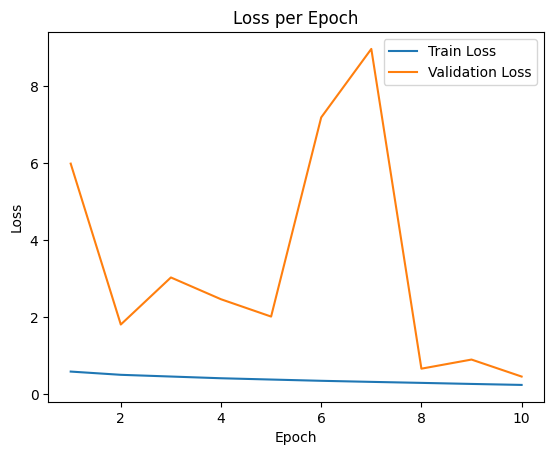

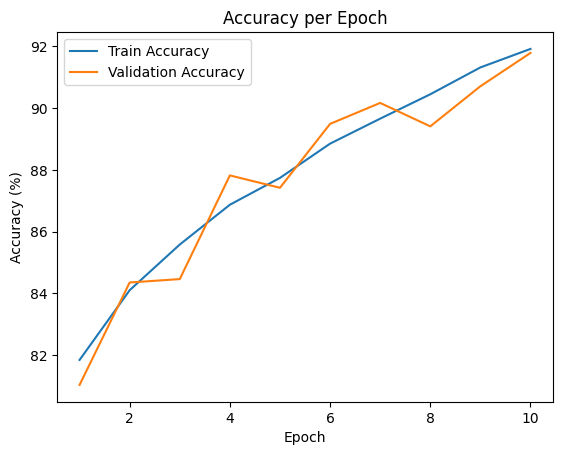

In [16]:
import matplotlib.pyplot as plt

epochs = list(range(1, 11))

plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss per Epoch")
plt.show()

plt.plot(epochs, train_accuracy, label="Train Accuracy")
plt.plot(epochs, val_accuracy, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Accuracy per Epoch")
plt.show()